In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix

In [2]:
# set file path
# Make sure there are three folders: Code, Data, Results to read from and write to
file_path = "C:/Users/jenan/OneDrive - Tufts Medicine/code/EDSValidation_Jennie"

In [3]:
# load data
with open(f"{file_path}/Data/patient.data.pkl", 'rb') as f:
    data = pickle.load(f)
patient_data = data['patient_data']
print(patient_data.shape)

(4429852, 27)


In [4]:
patient_data.columns

Index(['MRN', 'CSN', 'LCSN', 'sex', 'race', 'ethnicity', 'age',
       'admission.date.and.time', 'discharge.date.and.time', 'center',
       'prediction.date.and.time', 'model.score', 'model.prediction',
       'sep3.time.zero', 'sep3.outcome', 'admission.date', 'admission.time',
       'discharge.date', 'discharge.time', 'prediction.date',
       'prediction.time', 'time.point', 'max.time.point', 'time.sep3.outcome',
       'center.grouped', 'race.groups', 'age.groups'],
      dtype='object')

In [5]:
# set constants
max_days = 4 # why 4, what does this mean?
final_threshold = 30
look_back = 2 # hours
look_forwards = 8 # hours, could be between 8 and 12

In [6]:
# create a list of dfs, 1 df per LCSN
patient_df_list = [group for _, group in patient_data.groupby('LCSN')]
# remove dfs where patient doesn't have 2 hours of data
patient_df_list_filtered = [df for df in patient_df_list if len(df) >= 9]

Refractory Period

In [ ]:
# refractory period, turn off alarms
# when alarm goes off, turn off alarm for the next 8 alarms/the alarms do not go through
# alarm is if model.score >= 30

In [ ]:
# try for 1
patient_df = patient_df_list_filtered[1]
df_reset = patient_df.reset_index(drop=True)
df_reset['refractory_alarm'] = 0
i = 0
# if alarm at time point = 1, skip the next 8 hours, then continue the process
while i < len(df_reset):
    if df_reset.at[i, 'model.score'] >= 0.3:
        df_reset.at[i, 'refractory_alarm'] = 1
        for j in range(i + 1, min(i + 33, len(df_reset))):
            df_reset.at[j, 'refractory_alarm'] = 0
        i += 33
    else:
        df_reset.at[i, 'refractory_alarm'] = 0
        i += 1

In [8]:
df_reset[['model.score', 'time.point', 'refractory_alarm']].to_csv('test.csv', index = False)

In [ ]:
# do for all
refractory_period_df_list = []

for df in tqdm(patient_df_list_filtered):
    df_reset = df.reset_index(drop=True)
    df_reset['refractory_alarm'] = 0
    i = 0
    # if alarm at time point = 1, skip the next 8 hours, then continue the process
    while i < len(df_reset):
        if df_reset.at[i, 'model.score'] >= 0.3:
            df_reset.at[i, 'refractory_alarm'] = 1
            for j in range(i + 1, min(i + 33, len(df_reset))):
                df_reset.at[j, 'refractory_alarm'] = 0
            i += 33
        else:
            df_reset.at[i, 'refractory_alarm'] = 0
            i += 1
    refractory_period_df_list.append(df_reset)

100%|██████████| 26520/26520 [01:48<00:00, 244.90it/s]


In [11]:
len(refractory_period_df_list)

26520

Get Look back max and look forward outcome

In [12]:
# test for 1
patient_df = refractory_period_df_list[0]
alarm_pred_list = []
outcome_list = []

for time_point in patient_df['time.point']:
    if (time_point >= 8) and (patient_df['time.sep3.outcome'].iloc[time_point] != 1):
        alarm_pred = (patient_df.iloc[(time_point - 8):time_point]['refractory_alarm'] == 1).any()
        outcome = (patient_df.iloc[time_point:time_point + (8 * 4)]['time.sep3.outcome'] == 1).any()
        alarm_pred_list.append(alarm_pred)
        outcome_list.append(outcome)
    else:
        alarm_pred_list.append(-1)
        outcome_list.append(-1)

new_df = patient_df.copy()
new_df['look_back_alarm'] = alarm_pred_list
new_df['look_forward_outcome'] = outcome_list
new_df

,MRN,CSN,LCSN,sex,race,ethnicity,age,admission.date.and.time,discharge.date.and.time,center,...,prediction.time,time.point,max.time.point,time.sep3.outcome,center.grouped,race.groups,age.groups,refractory_alarm,look_back_alarm,look_forward_outcome
0,33860126,3084871618,3084871618,Female,White,"Not Hispanic, Latino/a, or Spanish Origin",73.0,2024-09-23 15:48:00.000,2024-09-30 16:15:00,TUFTS MEDICAL CENTER,...,16:01:31.000,0,11,0,Tufts,White,Older than 69.0 years,1,-1,-1
1,33860126,3084871618,3084871618,Female,White,"Not Hispanic, Latino/a, or Spanish Origin",73.0,2024-09-23 15:48:00.000,2024-09-30 16:15:00,TUFTS MEDICAL CENTER,...,16:15:01.000,1,11,0,Tufts,White,Older than 69.0 years,0,-1,-1
2,33860126,3084871618,3084871618,Female,White,"Not Hispanic, Latino/a, or Spanish Origin",73.0,2024-09-23 15:48:00.000,2024-09-30 16:15:00,TUFTS MEDICAL CENTER,...,16:31:28.000,2,11,0,Tufts,White,Older than 69.0 years,0,-1,-1
3,33860126,3084871618,3084871618,Female,White,"Not Hispanic, Latino/a, or Spanish Origin",73.0,2024-09-23 15:48:00.000,2024-09-30 16:15:00,TUFTS MEDICAL CENTER,...,16:45:01.000,3,11,0,Tufts,White,Older than 69.0 years,0,-1,-1
4,33860126,3084871618,3084871618,Female,White,"Not Hispanic, Latino/a, or Spanish Origin",73.0,2024-09-23 15:48:00.000,2024-09-30 16:15:00,TUFTS MEDICAL CENTER,...,17:01:28.000,4,11,0,Tufts,White,Older than 69.0 years,0,-1,-1
5,33860126,3084871618,3084871618,Female,White,"Not Hispanic, Latino/a, or Spanish Origin",73.0,2024-09-23 15:48:00.000,2024-09-30 16:15:00,TUFTS MEDICAL CENTER,...,17:15:01.000,5,11,0,Tufts,White,Older than 69.0 years,0,-1,-1
6,33860126,3084871618,3084871618,Female,White,"Not Hispanic, Latino/a, or Spanish Origin",73.0,2024-09-23 15:48:00.000,2024-09-30 16:15:00,TUFTS MEDICAL CENTER,...,17:31:29.000,6,11,0,Tufts,White,Older than 69.0 years,0,-1,-1
7,33860126,3084871618,3084871618,Female,White,"Not Hispanic, Latino/a, or Spanish Origin",73.0,2024-09-23 15:48:00.000,2024-09-30 16:15:00,TUFTS MEDICAL CENTER,...,17:45:01.000,7,11,0,Tufts,White,Older than 69.0 years,0,-1,-1
8,33860126,3084871618,3084871618,Female,White,"Not Hispanic, Latino/a, or Spanish Origin",73.0,2024-09-23 15:48:00.000,2024-09-30 16:15:00,TUFTS MEDICAL CENTER,...,18:01:28.000,8,11,0,Tufts,White,Older than 69.0 years,0,True,True
9,33860126,3084871618,3084871618,Female,White,"Not Hispanic, Latino/a, or Spanish Origin",73.0,2024-09-23 15:48:00.000,2024-09-30 16:15:00,TUFTS MEDICAL CENTER,...,18:15:01.000,9,11,0,Tufts,White,Older than 69.0 years,0,False,True


In [37]:
# at each time point, look at time frame 2 hours back, look forward 8 hours to see outcome
# track if alarm went off in past 2 hours, and outcome in next 8 hours
# start from time point 8 (since we need to look back 2 hours)
# loop through list of dfs
new_refractory_period_df_list = []
for patient_df in tqdm(refractory_period_df_list):
    alarm_pred_list = []
    outcome_list = []

    for time_point in patient_df['time.point']:
        if (time_point >= 8) and (patient_df['time.sep3.outcome'].iloc[time_point] != 1):
            alarm_pred = (patient_df.iloc[(time_point - 8):time_point]['refractory_alarm'] == 1).any()
            outcome = (patient_df.iloc[time_point:time_point + (8 * 4)]['time.sep3.outcome'] == 1).any()
            alarm_pred_list.append(alarm_pred)
            outcome_list.append(outcome)
        else:
            alarm_pred_list.append(-1)
            outcome_list.append(-1)
    
    new_df = patient_df.copy()
    new_df['look_back_alarm'] = alarm_pred_list
    new_df['look_forward_outcome'] = outcome_list
    new_refractory_period_df_list.append(new_df)

100%|██████████| 26520/26520 [07:38<00:00, 57.78it/s] 


In [39]:
# recombine dfs, save
combined_df = pd.concat(new_refractory_period_df_list, ignore_index=True)
combined_df.to_csv('Refractory_Period_Time_Dependent_Data.csv', index = False)

In [40]:
# remove all rows where look_back_max or look_forward_outcome are -1
combined_df_filtered = combined_df[~((combined_df['look_back_alarm'] == -1) & (combined_df['look_forward_outcome'] == -1))]
print(len(combined_df_filtered))

4183279


In [41]:
# save
combined_df_filtered.to_csv('Refractory_Period_Time_Dependent_Data.csv', index = False)

In [42]:
# get max time point
combined_df_filtered['time.point'].max()

np.int64(10145)

In [43]:
# replace true in look_forward_outcome and look_back_alarm with 1 and false with 0
combined_df_filtered['look_forward_outcome'] = combined_df_filtered['look_forward_outcome'].astype(int)
combined_df_filtered['look_back_alarm'] = combined_df_filtered['look_back_alarm'].astype(int)

C:\Users\jenan\AppData\Local\Temp\ipykernel_13920\1240577249.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['look_forward_outcome'] = combined_df_filtered['look_forward_outcome'].astype(int)
C:\Users\jenan\AppData\Local\Temp\ipykernel_13920\1240577249.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['look_back_alarm'] = combined_df_filtered['look_back_alarm'].astype(int)


In [44]:
# create list of dfs grouped by time point
time_point_df_list = [group for _, group in combined_df_filtered.groupby('time.point')]

In [45]:
len(time_point_df_list)

10138

In [46]:
# get metrics at each time point

# loop through each time point
time_point = []
prevalence = []
tp = []
fp = []
tn = []
fn = []
auc = []
sensitivity = []
specificity = []
ppv = []
npv = []

for df in tqdm(time_point_df_list):
    predictions = df['look_back_alarm']
    outcomes = df['look_forward_outcome']

    time_point.append(df['time.point'].iloc[0])

    prevalence.append(np.mean(outcomes))
    tp_val = np.sum((outcomes == 1) & (predictions == 1))  
    fp_val = np.sum((outcomes == 0) & (predictions == 1))  
    tn_val = np.sum((outcomes == 0) & (predictions == 0))  
    fn_val = np.sum((outcomes == 1) & (predictions == 0))  
    tp.append(tp_val)
    fp.append(fp_val)
    tn.append(tn_val)
    fn.append(fn_val)

    auc_value = roc_auc_score(outcomes, predictions)
    auc.append(auc_value)

    sensitivity_value = tp_val / (tp_val + fn_val) if tp_val + fn_val > 0 else 0
    sensitivity.append(sensitivity_value)
    specificity_value = tn_val / (tn_val + fp_val) if tn_val + fp_val > 0 else 0
    specificity.append(specificity_value)

    ppv_value = tp_val / (tp_val + fp_val) if tp_val + fp_val > 0 else 0
    ppv.append(ppv_value)
    npv_value = tn_val / (tn_val + fn_val) if tn_val + fn_val > 0 else 0
    npv.append(npv_value)

  3%|▎         | 325/10138 [00:00<00:13, 702.46it/s]c:\Users\jenan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\jenan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\jenan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\jenan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
  6%|▋         | 641/10138 [00:00<00:12,

In [47]:
# get df of results
results_df = pd.DataFrame({
    'Time Point': time_point,
    'Prevalence': prevalence,
    'TP': tp,
    'FP': fp,
    'TN': tn,
    'FN': fn,
    'AUC': auc,
    'Sensitivity': sensitivity,
    'Specificity': specificity,
    'PPV': ppv,
    'NPV': npv
})

In [48]:
# reorder results df
results_df.sort_values(by='Time Point', ascending=True, inplace=False)
results_df

,Time Point,Prevalence,TP,FP,TN,FN,AUC,Sensitivity,Specificity,PPV,NPV
0,8,0.012907,182,2608,23548,160,0.716227,0.532164,0.900291,0.065233,0.993251
1,9,0.012376,69,649,24249,243,0.597544,0.221154,0.973934,0.096100,0.990078
2,10,0.012193,49,407,23249,243,0.575302,0.167808,0.982795,0.107456,0.989656
3,11,0.011971,32,259,22190,240,0.553055,0.117647,0.988463,0.109966,0.989300
4,12,0.011651,20,212,21081,231,0.534862,0.079681,0.990044,0.086207,0.989161
...,...,...,...,...,...,...,...,...,...,...,...
10133,10141,0.000000,0,0,1,0,NaN,0.000000,1.000000,0.000000,1.000000
10134,10142,0.000000,0,0,1,0,NaN,0.000000,1.000000,0.000000,1.000000
10135,10143,0.000000,0,0,1,0,NaN,0.000000,1.000000,0.000000,1.000000
10136,10144,0.000000,0,0,1,0,NaN,0.000000,1.000000,0.000000,1.000000


In [49]:
# save
results_df.to_csv('Time_dependent_refractory_period_results.csv', index = False)

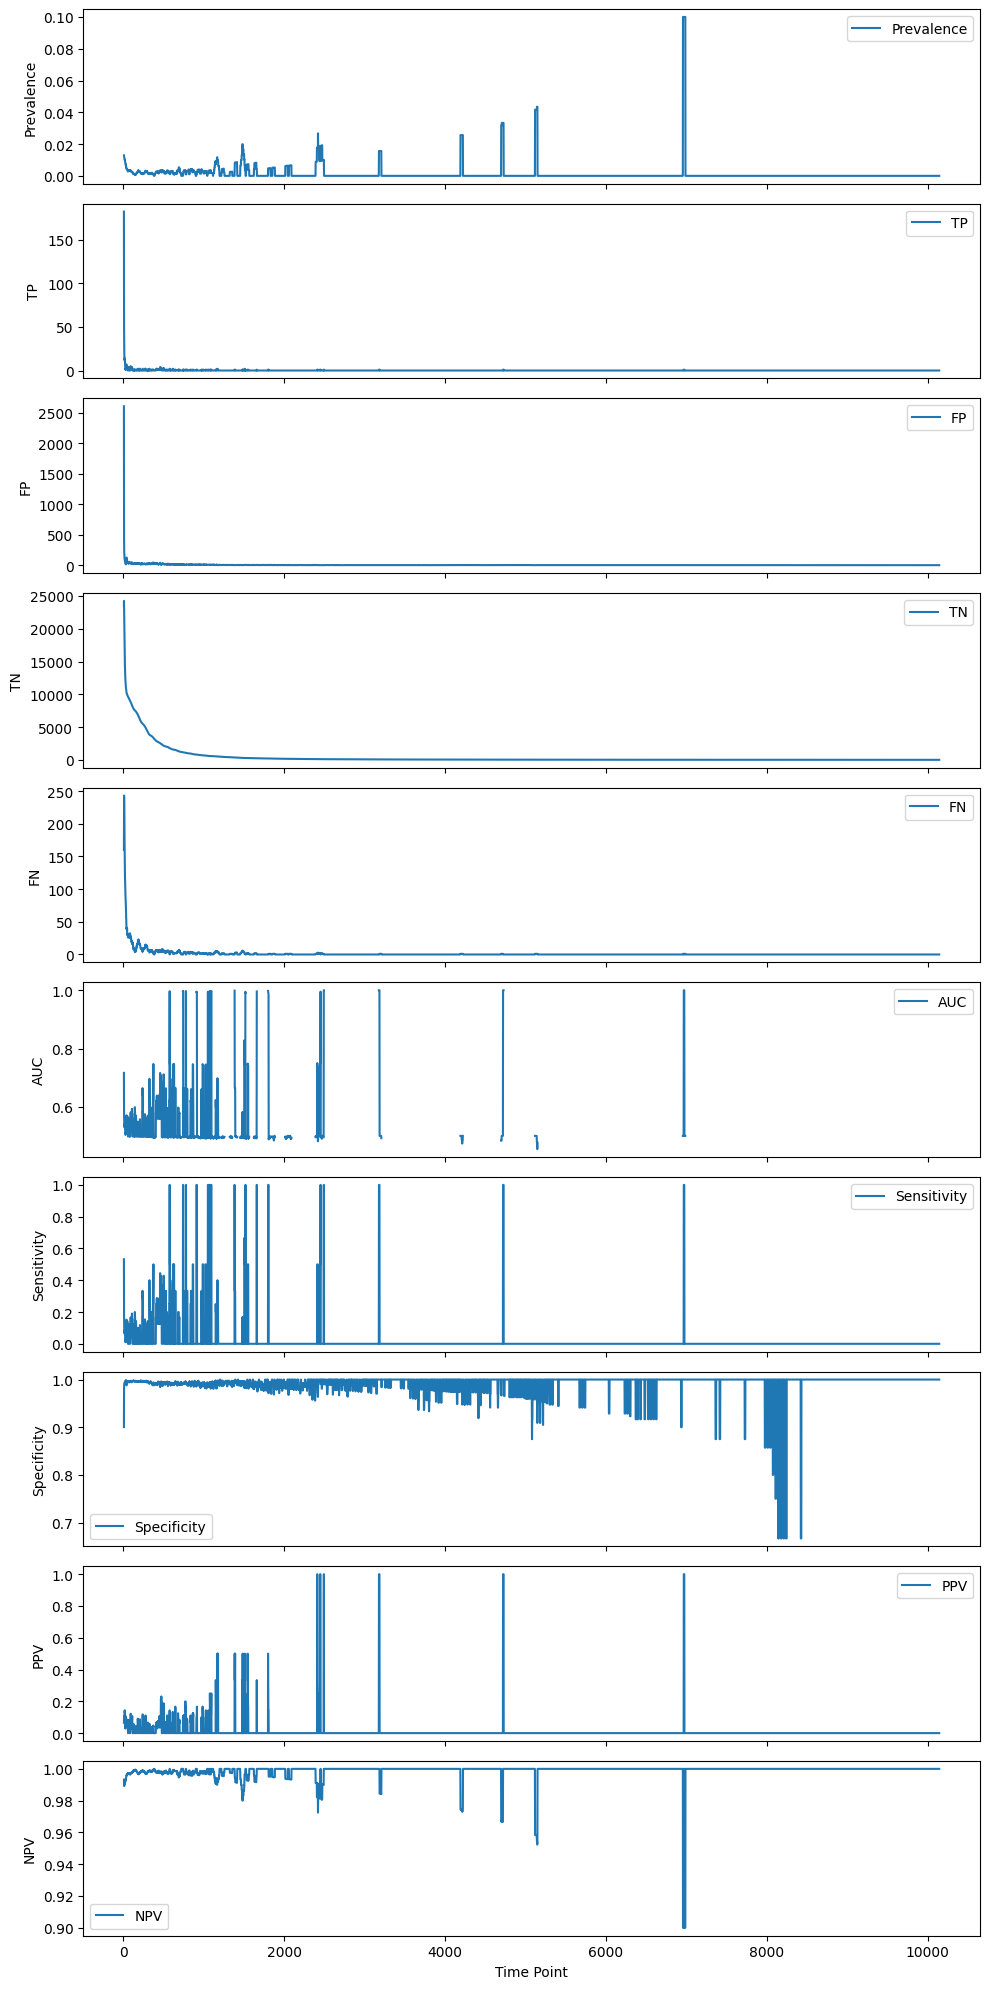

In [50]:
# plot
fig, axs = plt.subplots(10, 1, sharex=True, figsize=(10, 20))

axs[0].plot(results_df['Time Point'], results_df['Prevalence'], label='Prevalence')
axs[0].set_ylabel('Prevalence')
axs[0].legend()

axs[1].plot(results_df['Time Point'], results_df['TP'], label='TP')
axs[1].set_ylabel('TP')
axs[1].legend()

axs[2].plot(results_df['Time Point'], results_df['FP'], label='FP')
axs[2].set_ylabel('FP')
axs[2].legend()

axs[3].plot(results_df['Time Point'], results_df['TN'], label='TN')
axs[3].set_ylabel('TN')
axs[3].legend()

axs[4].plot(results_df['Time Point'], results_df['FN'], label='FN')
axs[4].set_ylabel('FN')
axs[4].legend()

axs[5].plot(results_df['Time Point'], results_df['AUC'], label='AUC')
axs[5].set_ylabel('AUC')
axs[5].legend()

axs[6].plot(results_df['Time Point'], results_df['Sensitivity'], label='Sensitivity')
axs[6].set_ylabel('Sensitivity')
axs[6].legend()

axs[7].plot(results_df['Time Point'], results_df['Specificity'], label='Specificity')
axs[7].set_ylabel('Specificity')
axs[7].legend()

axs[8].plot(results_df['Time Point'], results_df['PPV'], label='PPV')
axs[8].set_ylabel('PPV')
axs[8].legend()

axs[9].plot(results_df['Time Point'], results_df['NPV'], label='NPV')
axs[9].set_ylabel('NPV')
axs[9].legend()

# only show every 96 ticks (every day) eventually
axs[9].set_xlabel('Time Point')

# Adjust spacing between subplots
plt.tight_layout()

# Show plot
plt.show()